In [16]:
import csv
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd 
 # ------------------------- # Imports from your ridge helper module # ---------------- 
from ridge_regression_functions import ( 
    load_all_trials, split_trials_by_condition, concat_trials,
    ) # make sure ridge_regression_functions.py is on your PYTHONPATH 
    # and that it is the same one you used for fitting the weights.

# Try to use SciPy's griddata for smooth interpolation; fallback to IDW if unavailable.
try:
    from scipy.interpolate import griddata
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False

# --- Configuration ---
CSV_PATH = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_UPDATE.csv")
OUT_PATH = CSV_PATH.with_name("dfk_ridge_TMP_mean_scalpmaps.png")

# IMPORTANT: use the same roots you used when fitting the ridge models 
PUPIL_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow") 
EEG_ROOT = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow") 
# Extra trim after lag alignment (ms). 
# Set this to the same trim_ms you used in your CV script (e.g. 300 or 5000). 
TRIM_MS = 100

# IMPORTANT: channel ordering must match the weight-vector ordering
POS = {
    "AFz": (0.0,  0.75),
    "AF3": (-0.35, 0.70),
    "AF4": ( 0.35, 0.70),

    "Fz":  (0.0,  0.55),
    "F1":  (-0.15, 0.52),
    "F2":  ( 0.15, 0.52),
    "F3":  (-0.30, 0.50),
    "F4":  ( 0.30, 0.50),

    "FC1": (-0.18, 0.32),
    "FC2": ( 0.18, 0.32),
    "FC3": (-0.35, 0.30),
    "FC4": ( 0.35, 0.30),

    "Cz":  (0.0,  0.10),
    "C1":  (-0.18, 0.10),
    "C2":  ( 0.18, 0.10),
    "C3":  (-0.36, 0.08),
    "C4":  ( 0.36, 0.08),
}
FRONTAL_MIDLINE = ['AFz','AF3','AF4','Fz','F1','F2','F3','F4','FC3','FC1','FC2','FC4','Cz','C3','C1','C2','C4']

# --- Robust parser for weight strings ---
def parse_weight_str(s):
    """
    Parse w_star / w0_lam strings into 1D float array.
    Tries to handle things like:
    - "[0.1 0.2 0.3]"
    - "0.1,0.2,0.3"
    - "0.1;0.2;0.3"
    - "array([0.1, 0.2, 0.3])"
    """
    if s is None:
        return None
    s = str(s).strip()
    if not s:
        return None

    # Remove common wrappers
    # e.g. "array([...])" -> "[...]"
    s = re.sub(r"^array\((.*)\)$", r"\1", s)

    # Strip outer brackets if present
    s = s.strip("[]()")

    # Replace commas and semicolons etc with spaces
    s = s.replace(",", " ").replace(";", " ")

    # Replace anything that is NOT [0-9, sign, dot, exp, space] with space
    # Keeps digits, +/-, dot, e/E, and whitespace
    s_clean = re.sub(r"[^0-9eE+\-\. ]+", " ", s)

    # Collapse multiple spaces
    s_clean = re.sub(r"\s+", " ", s_clean).strip()

    if not s_clean:
        return None

    arr = np.fromstring(s_clean, sep=" ")

    return arr if arr.size > 0 else None

def zscore_per_subject(W):
    W = np.asarray(W, float)
    mean = W.mean(axis=1, keepdims=True)
    std = W.std(axis=1, keepdims=True, ddof=0)
    # avoid division by zero
    std[std == 0] = 1.0
    return (W - mean) / std

def idw_interpolate(points, values, gx, gy, power=2.0, eps=1e-12):
    px = points[:, 0][:, None, None]
    py = points[:, 1][:, None, None]
    dx = gx[None, :, :] - px
    dy = gy[None, :, :] - py
    d2 = dx*dx + dy*dy
    w = 1.0 / (d2 + eps)**(power/2)
    num = (w * values[:, None, None]).sum(axis=0)
    den = w.sum(axis=0)
    return num / (den + eps)

def compute_grid(z, xy, GX, GY, mask, normalise = False):
    z = np.asarray(z, dtype=float)
    if normalise:
        mu = z.mean()
        sd = z.std(ddof=0)
        if sd == 0:
            z_std = np.zeros_like(z)
        else:
            z_std = (z - mu) / sd
        z = z_std  

    if _HAS_SCIPY:
        GZ = griddata(xy, z_std, (GX, GY), method="cubic")
        nan_mask = np.isnan(GZ)
        if nan_mask.any():
            GZ_idw = idw_interpolate(xy, z_std, GX, GY, power=2.0)
            GZ[nan_mask] = GZ_idw[nan_mask]
    else:
        GZ = idw_interpolate(xy, z_std, GX, GY, power=2.0)

    return np.ma.array(GZ, mask=~mask)

def parse_subject_id(val):
    """
    Convert 'subject' column to an integer id.
    Handles 'sub-042', '42', 42, etc.
    """
    if val is None:
        return None
    try:
        # if it's numeric-ish already
        return int(float(val))
    except (ValueError, TypeError):
        s = str(val)
        m = re.search(r"(\d+)", s)
        if not m:
            return None
        return int(m.group(1))

def channel_loadings(X, w):
    """
    Given X (T x C) and weights w (C,), compute
    loadings_j = corr(X[:, j], X @ w) for each channel j.
    """
    X = np.asarray(X, float)
    w = np.asarray(w, float).ravel()
    if X.shape[1] != w.shape[0]:
        raise ValueError(
            f"Dimension mismatch: X has {X.shape[1]} channels but w has length {w.shape[0]}"
        )

    u = X @ w
    u = np.asarray(u).ravel()

    std_u = u.std(ddof=0)
    if std_u == 0:
        return np.full(X.shape[1], np.nan)

    L = np.empty(X.shape[1], dtype=float)
    for j in range(X.shape[1]):
        xj = X[:, j]
        std_xj = xj.std(ddof=0)
        if std_xj == 0:
            L[j] = np.nan
        else:
            L[j] = np.corrcoef(xj, u)[0, 1]
    return L

def normalise_w_cov(X, w, eps=1e-12):
    """
    Normalize weights so that w^T Sxx w = 1, where
    Sxx is the covariance of X (T x C).

    Returns a rescaled copy of w.
    """
    X = np.asarray(X, float)
    w = np.asarray(w, float).ravel()

    # center like np.cov does
    Xc = X - X.mean(axis=0, keepdims=True)
    n = Xc.shape[0]
    if n <= 1:
        return w

    Sxx = (Xc.T @ Xc) / max(n - 1, 1)   # covariance (ddof=1)
    quad = float(w.T @ Sxx @ w)
    if quad <= eps:
        # degenerate case: don't rescale
        return w

    scale = 1.0 / np.sqrt(quad)
    return w * scale


Row 0:
  raw w_star: [[-0.00622191]
 [-0.01072822]
 [-0.01729788]
 [ 0.01101155]
 [ 0.00741237]
 [ 0.00530986]
 [-0.00046109]
 [-0.01053202]
 [-0.00583491]
 [ 0.00207283]
 [-0.00054021]
 [-0.00829463]
 [ 0.00618832]
 [ 0.0032422 ]
 [ 0.01498417]
 [ 0.01996334]
 [-0.00156674]]
  parsed w_star shape: (17,)
  raw w0_lam/w_lam0: [[ 0.01290034]
 [-0.04252366]
 [-0.11884486]
 [ 0.07600636]
 [ 0.00184195]
 [ 0.06924578]
 [ 0.00951834]
 [-0.03207729]
 [-0.02036987]
 [-0.00638661]
 [-0.06573272]
 [-0.01914925]
 [-0.03113696]
 [ 0.00095446]
 [ 0.06791084]
 [ 0.16644282]
 [-0.00171876]]
  parsed w_lam0 shape: (17,)
Row 1:
  raw w_star: [[ 0.03540181]
 [ 0.01684947]
 [ 0.03865643]
 [ 0.00081652]
 [ 0.01081237]
 [ 0.00579106]
 [ 0.02675506]
 [-0.00010681]
 [ 0.02556526]
 [ 0.05756149]
 [-0.00340362]
 [-0.00594822]
 [-0.03874772]
 [-0.04190842]
 [-0.01915208]
 [-0.03046645]
 [-0.03422261]]
  parsed w_star shape: (17,)
  raw w0_lam/w_lam0: [[ 0.06012006]
 [ 0.01637647]
 [ 0.09192611]
 [-0.00364763]
 

C:\Users\cdd\AppData\Local\Temp\ipykernel_21104\389239713.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust


Saved scalp maps to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_TMP_mean_scalpmaps.png


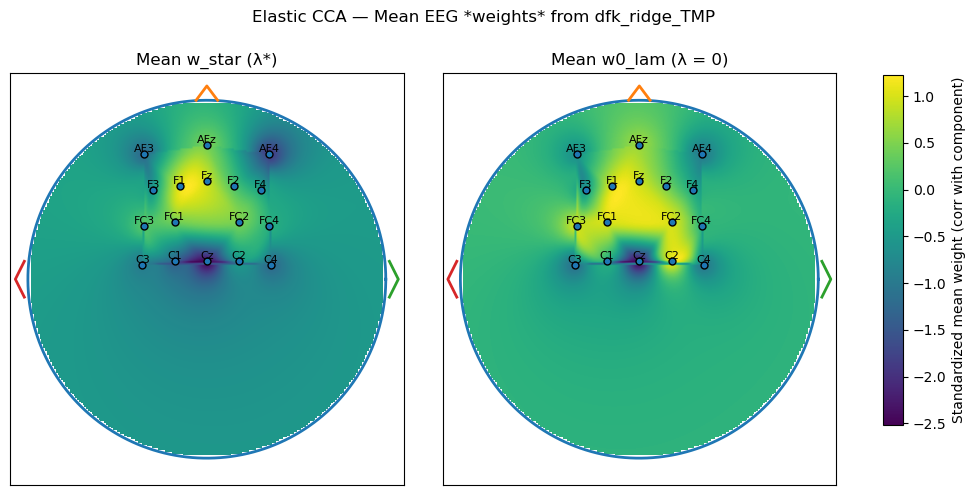

In [12]:

# --- Load dfk_ridge_TMP.csv and accumulate weights ---
W_star_list = []
W_lam0_list = []

with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for i, row in enumerate(reader):
        ws = parse_weight_str(row.get("w_star"))
        wl = parse_weight_str(row.get("w_lam0") or row.get("w0_lam"))

        # Debug: show first few parsed shapes
        if i < 3:
            print(f"Row {i}:")
            print("  raw w_star:", row.get("w_star"))
            print("  parsed w_star shape:", None if ws is None else ws.shape)
            print("  raw w0_lam/w_lam0:", row.get("w0_lam") or row.get("w_lam0"))
            print("  parsed w_lam0 shape:", None if wl is None else wl.shape)

        if ws is None or wl is None:
            continue

        W_star_list.append(ws)
        W_lam0_list.append(wl)

if not W_star_list:
    raise RuntimeError("No valid weight vectors found in w_star / w0_lam columns.")

# Stack
W_star = np.vstack(W_star_list)
W_lam0 = np.vstack(W_lam0_list)

print("W_star shape:", W_star.shape)
print("W_lam0 shape:", W_lam0.shape)

n_subj, n_chan = W_star.shape

if n_chan != len(FRONTAL_MIDLINE):
    raise RuntimeError(
        f"Number of channels in weights ({n_chan}) != number in POS ({len(FRONTAL_MIDLINE)}).\n"
        f"- If {n_chan} is correct, update POS/CHANNELS to have {n_chan} entries\n"
        f"- If you expected more channels, check how w_star / w0_lam are stored in the CSV."
    )

print(f"Loaded {n_subj} subjects, {n_chan} channels.")

# --- Compute mean weights across subjects ---
#mean_star = W_star.mean(axis=0)
#mean_lam0 = W_lam0.mean(axis=0)
# W_star, W_lam0: shape (n_subj, n_chan)

W_star_zsubj = zscore_per_subject(W_star)
W_lam0_zsubj = zscore_per_subject(W_lam0)

# Now average the standardized maps
mean_star = W_star_zsubj.mean(axis=0)   # (n_chan,)
mean_lam0 = W_lam0_zsubj.mean(axis=0)

# --- Geometry / grid for topomaps ---
xy = np.array([POS[ch] for ch in FRONTAL_MIDLINE])

N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0

GZ_star = compute_grid(mean_star, xy, GX, GY, mask, normalise = True)
GZ_lam0 = compute_grid(mean_lam0, xy, GX, GY, mask, normalise = True)

# --- Plot side-by-side scalp maps ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, GZ_masked, title in zip(
    axes,
    [GZ_star, GZ_lam0],
    ["Mean w_star (λ*)", "Mean w0_lam (λ = 0)"]
):
    im = ax.imshow(
        GZ_masked,
        origin="lower",
        extent=(-1, 1, -1, 1),
        interpolation="bilinear",
    )

    # head outline
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=2)

    # nose
    nose_x = np.array([-0.06, 0.0, 0.06])
    nose_y = np.array([1.00, 1.08, 1.00])
    ax.plot(nose_x, nose_y, linewidth=2)

    # ears
    ear_x = np.array([1.02, 1.07, 1.02])
    ear_y = np.array([0.10, 0.00, -0.10])
    ax.plot( ear_x,  ear_y, linewidth=2)
    ax.plot(-ear_x,  ear_y, linewidth=2)

    # electrodes + labels
    ex, ey = xy[:, 0], xy[:, 1]
    ax.scatter(ex, ey, s=25, edgecolors="k")
    for ch, (cx, cy) in POS.items():
        ax.text(cx, cy, ch, ha="center", va="bottom", fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Standardized mean weight (corr with component)")

fig.suptitle("Elastic CCA — Mean EEG *weights* from dfk_ridge_TMP", y=0.98)
fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust
fig.savefig(OUT_PATH, dpi=200)
print(f"Saved scalp maps to: {OUT_PATH}")
plt.show()


Included 53 subjects in loading-based scalp map.
Loaded 53 subjects, 17 channels for loadings.
Saved per-subject loadings to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_TMP_loadings_per_subject.csv


C:\Users\cdd\AppData\Local\Temp\ipykernel_11816\991955438.py:411: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust


Saved scalp maps to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_UPDATE_mean_scalpmaps_LOADINGS.png


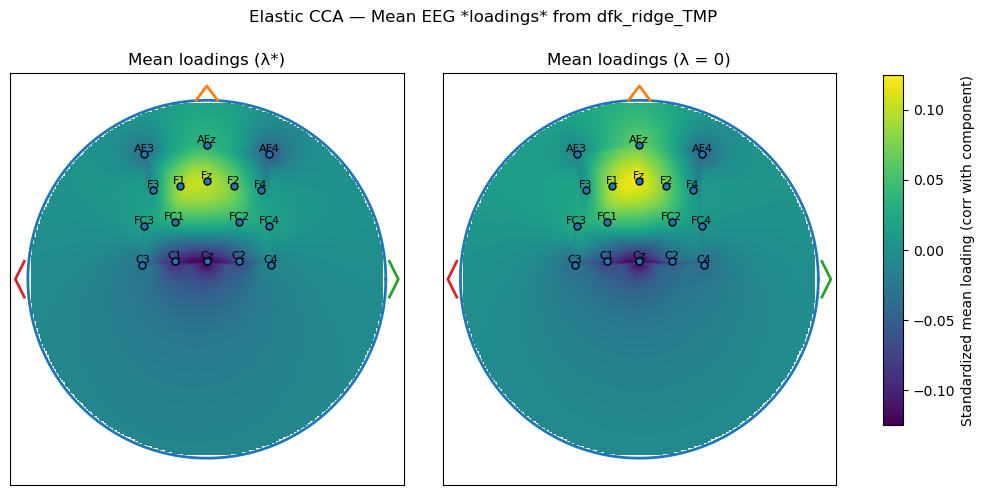

In [13]:
# -------------------------------------------------------------------
# Geometry / grid for topomaps
# -------------------------------------------------------------------
xy = np.array([POS[ch] for ch in FRONTAL_MIDLINE])

N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0

# -------------------------------------------------------------------
# Load weights from CSV, compute loadings per subject
# -------------------------------------------------------------------
W_star_list = []
W_lam0_list = []
L_star_list = []
L_lam0_list = []
subjects_used = []

with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for i, row in enumerate(reader):
        ws = parse_weight_str(row.get("w_star"))
        wl = parse_weight_str(row.get("w_lam0") or row.get("w0_lam"))
        if ws is None or wl is None:
            continue

        subj = parse_subject_id(row.get("subject"))
        if subj is None:
            print(f"Row {i}: could not parse subject from '{row.get('subject')}', skipping.")
            continue

        # best lag in ms → samples (10 ms/sample at 100 Hz)
        try:
            lag_star_ms = float(row.get("best_lag_ms_star"))
            lag_lam0_ms = float(row.get("best_lag_ms_lam0"))
        except (TypeError, ValueError):
            print(f"Row {i}: missing/invalid lag columns, skipping.")
            continue

        best_s_star = int(round(lag_star_ms / 10.0))
        best_s_lam0 = int(round(lag_lam0_ms / 10.0))

        # Load all trials and keep memory condition only
        all_trials = load_all_trials(subj, eeg_root=EEG_ROOT, pupil_root=PUPIL_ROOT)
        if not all_trials:
            print(f"sub-{subj:03d}: no valid trials found, skipping.")
            continue

        trials_memory, _ = split_trials_by_condition(all_trials)
        if not trials_memory:
            print(f"sub-{subj:03d}: no MEMORY trials, skipping.")
            continue

        # X_all for λ* and λ=0 (use their own best lags)
        X_star, _ = concat_trials(trials_memory, shift=best_s_star, trim=TRIM_MS)
        X_lam0, _ = concat_trials(trials_memory, shift=best_s_lam0, trim=TRIM_MS)

        if X_star.size == 0 or X_lam0.size == 0:
            print(f"sub-{subj:03d}: empty X after concat (lag* {best_s_star}, lag0 {best_s_lam0}), skipping.")
            continue

        # Sanity: channels must match number of weights
        if X_star.shape[1] != len(ws) or X_lam0.shape[1] != len(wl):
            print(
                f"sub-{subj:03d}: channel-weight mismatch "
                f"(X_star: {X_star.shape[1]}, len(ws): {len(ws)}, "
                f"X_lam0: {X_lam0.shape[1]}, len(wl): {len(wl)}), skipping."
            )
            continue

        # Compute per-channel loadings
        L_star = channel_loadings(X_star, ws)
        L_lam0 = channel_loadings(X_lam0, wl)

        if np.all(np.isnan(L_star)) or np.all(np.isnan(L_lam0)):
            print(f"sub-{subj:03d}: all-NaN loadings, skipping.")
            continue

        subjects_used.append(subj)
        W_star_list.append(ws)
        W_lam0_list.append(wl)
        L_star_list.append(L_star)
        L_lam0_list.append(L_lam0)

print(f"Included {len(subjects_used)} subjects in loading-based scalp map.")

if not L_star_list:
    raise RuntimeError("No valid loading vectors computed; check CSV columns and paths.")


# -------------------------------------------------------------------
# Stack and z-score per subject (across channels)
# -------------------------------------------------------------------
W_star = np.vstack(W_star_list)
W_lam0 = np.vstack(W_lam0_list)
L_star = np.vstack(L_star_list)
L_lam0 = np.vstack(L_lam0_list)

n_subj, n_chan = L_star.shape
if n_chan != len(FRONTAL_MIDLINE):
    raise RuntimeError(
        f"Number of channels in loadings ({n_chan}) != number in POS ({len(FRONTAL_MIDLINE)}).\n"
        f"- If {n_chan} is correct, update POS/CHANNELS to have {n_chan} entries.\n"
        f"- If you expected more channels, check how epochs and weights are stored."
    )

print(f"Loaded {n_subj} subjects, {n_chan} channels for loadings.")

# -------------------------------------------------------------------
# Save per-subject loadings to CSV
# -------------------------------------------------------------------
rows = []
for idx, subj in enumerate(subjects_used):
    row = {"subject": subj}
    # raw (non z-scored) loadings per channel
    for j, ch in enumerate(FRONTAL_MIDLINE):
        row[f"loading_star_{ch}"] = L_star[idx, j]
        row[f"loading_lam0_{ch}"] = L_lam0[idx, j]
    rows.append(row)

df_loadings = pd.DataFrame(rows)

LOADINGS_CSV_PATH = CSV_PATH.with_name("dfk_ridge_TMP_loadings_per_subject.csv")
df_loadings.to_csv(LOADINGS_CSV_PATH, index=False)
print(f"Saved per-subject loadings to: {LOADINGS_CSV_PATH}")


#L_star_zsubj = zscore_per_subject(L_star)
#L_lam0_zsubj = zscore_per_subject(L_lam0)

mean_star = L_star.mean(axis=0)   # (n_chan,)
mean_lam0 = L_lam0.mean(axis=0)


# -------------------------------------------------------------------
# Interpolate onto scalp grid
# -------------------------------------------------------------------
GZ_star = compute_grid(mean_star, xy, GX, GY, mask)
GZ_lam0 = compute_grid(mean_lam0, xy, GX, GY, mask)

# Global min/max across both maps
vmin = np.nanmin([GZ_star.min(), GZ_lam0.min()])
vmax = np.nanmax([GZ_star.max(), GZ_lam0.max()])

# (optional) make the scale symmetric around 0
v = max(abs(vmin), abs(vmax))
vmin, vmax = -v, v

norm = plt.Normalize(vmin=vmin, vmax=vmax)


# -------------------------------------------------------------------
# Plot side-by-side scalp maps (loadings)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, GZ_masked, title in zip(
    axes,
    [GZ_star, GZ_lam0],
    ["Mean loadings (λ*)", "Mean loadings (λ = 0)"],
):
    im = ax.imshow(
        GZ_masked,
        origin="lower",
        extent=(-1, 1, -1, 1),
        interpolation="bilinear",
        norm=norm,
    )

    # head outline
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=2)

    # nose
    nose_x = np.array([-0.06, 0.0, 0.06])
    nose_y = np.array([1.00, 1.08, 1.00])
    ax.plot(nose_x, nose_y, linewidth=2)

    # ears
    ear_x = np.array([1.02, 1.07, 1.02])
    ear_y = np.array([0.10, 0.00, -0.10])
    ax.plot( ear_x,  ear_y, linewidth=2)
    ax.plot(-ear_x,  ear_y, linewidth=2)

    # electrodes + labels
    ex, ey = xy[:, 0], xy[:, 1]
    ax.scatter(ex, ey, s=25, edgecolors="k")
    for ch, (cx, cy) in POS.items():
        ax.text(cx, cy, ch, ha="center", va="bottom", fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Standardized mean loading (corr with component)")

fig.suptitle("Elastic CCA — Mean EEG *loadings* from dfk_ridge_TMP", y=0.98)
fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust
fig.savefig(OUT_PATH, dpi=200)
print(f"Saved scalp maps to: {OUT_PATH}")
plt.show()


In [17]:
# -------------------------------------------------------------------
# Geometry / grid for topomaps
# -------------------------------------------------------------------
xy = np.array([POS[ch] for ch in FRONTAL_MIDLINE])

N = 200
grid_x = np.linspace(-1.0, 1.0, N)
grid_y = np.linspace(-1.0, 1.0, N)
GX, GY = np.meshgrid(grid_x, grid_y)
mask = (GX**2 + GY**2) <= 1.0

# -------------------------------------------------------------------
# Load weights from CSV, compute loadings per subject
# -------------------------------------------------------------------
W_star_list = []
W_lam0_list = []
L_star_list = []
L_lam0_list = []
subjects_used = []

with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)

    for i, row in enumerate(reader):
        ws = parse_weight_str(row.get("w_star"))
        wl = parse_weight_str(row.get("w_lam0") or row.get("w0_lam"))
        if ws is None or wl is None:
            continue

        subj = parse_subject_id(row.get("subject"))
        if subj is None:
            print(f"Row {i}: could not parse subject from '{row.get('subject')}', skipping.")
            continue

        # best lag in ms → samples (10 ms/sample at 100 Hz)
        try:
            lag_star_ms = float(row.get("best_lag_ms_star"))
            lag_lam0_ms = float(row.get("best_lag_ms_lam0"))
        except (TypeError, ValueError):
            print(f"Row {i}: missing/invalid lag columns, skipping.")
            continue

        best_s_star = int(round(lag_star_ms / 10.0))
        best_s_lam0 = int(round(lag_lam0_ms / 10.0))

        # Load all trials and keep memory condition only
        all_trials = load_all_trials(subj, eeg_root=EEG_ROOT, pupil_root=PUPIL_ROOT)
        if not all_trials:
            print(f"sub-{subj:03d}: no valid trials found, skipping.")
            continue

        trials_memory, _ = split_trials_by_condition(all_trials)
        if not trials_memory:
            print(f"sub-{subj:03d}: no MEMORY trials, skipping.")
            continue

        # X_all for λ* and λ=0 (use their own best lags)
        X_star, _ = concat_trials(trials_memory, shift=best_s_star, trim=TRIM_MS)
        X_lam0, _ = concat_trials(trials_memory, shift=best_s_lam0, trim=TRIM_MS)

        if X_star.size == 0 or X_lam0.size == 0:
            print(f"sub-{subj:03d}: empty X after concat (lag* {best_s_star}, lag0 {best_s_lam0}), skipping.")
            continue

        # Sanity: channels must match number of weights
        if X_star.shape[1] != len(ws) or X_lam0.shape[1] != len(wl):
            print(
                f"sub-{subj:03d}: channel-weight mismatch "
                f"(X_star: {X_star.shape[1]}, len(ws): {len(ws)}, "
                f"X_lam0: {X_lam0.shape[1]}, len(wl): {len(wl)}), skipping."
            )
            continue

        # Compute per-channel norm weights
        ws_norm = normalise_w_cov(X_star, ws)
        wl_norm = normalise_w_cov(X_lam0, wl)

        if np.all(np.isnan(ws_norm)) or np.all(np.isnan(wl_norm)):
            print(f"sub-{subj:03d}: all-NaN normalized weights, skipping.")
            continue

        subjects_used.append(subj)
        W_star_list.append(ws_norm)
        W_lam0_list.append(wl_norm)

print(f"Included {len(subjects_used)} subjects in loading-based scalp map.")

if not W_star_list:
    raise RuntimeError("No valid normalized weight vectors computed; check CSV columns and paths.")


# -------------------------------------------------------------------
# Stack and z-score per subject (across channels)
# -------------------------------------------------------------------
W_star = np.vstack(W_star_list)
W_lam0 = np.vstack(W_lam0_list)

n_subj, n_chan = W_star.shape
if n_chan != len(FRONTAL_MIDLINE):
    raise RuntimeError(
        f"Number of channels in loadings ({n_chan}) != number in POS ({len(FRONTAL_MIDLINE)}).\n"
        f"- If {n_chan} is correct, update POS/CHANNELS to have {n_chan} entries.\n"
        f"- If you expected more channels, check how epochs and weights are stored."
    )

print(f"Loaded {n_subj} subjects, {n_chan} channels for normalized weights.")

# -------------------------------------------------------------------
# Save per-subject normalized weights to CSV
# -------------------------------------------------------------------
rows = []
for idx, subj in enumerate(subjects_used):
    row = {"subject": subj}
    # raw (non z-scored) loadings per channel
    for j, ch in enumerate(FRONTAL_MIDLINE):
        row[f"weight_star_{ch}"] = W_star[idx, j]
        row[f"weight_lam0_{ch}"] = W_lam0[idx, j]
    rows.append(row)

df_norm_weights = pd.DataFrame(rows)

NORM_W_CSV_PATH = CSV_PATH.with_name("dfk_ridge_norm_w_per_subject.csv")
df_norm_weights.to_csv(NORM_W_CSV_PATH, index=False)
print(f"Saved per-subject normalised weights to: {NORM_W_CSV_PATH}")


#L_star_zsubj = zscore_per_subject(L_star)
#L_lam0_zsubj = zscore_per_subject(L_lam0)

mean_star = W_star.mean(axis=0)   # (n_chan,)
mean_lam0 = W_lam0.mean(axis=0)


# -------------------------------------------------------------------
# Interpolate onto scalp grid
# -------------------------------------------------------------------
GZ_star = compute_grid(mean_star, xy, GX, GY, mask, normalise = True)
GZ_lam0 = compute_grid(mean_lam0, xy, GX, GY, mask, normalise = True)


# -------------------------------------------------------------------
# Plot side-by-side scalp maps (loadings)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, GZ_masked, title in zip(
    axes,
    [GZ_star, GZ_lam0],
    ["Mean weights (λ*)", "Mean weights (λ = 0)"],
):
    im = ax.imshow(
        GZ_masked,
        origin="lower",
        extent=(-1, 1, -1, 1),
        interpolation="bilinear",
    )

    # head outline
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=2)

    # nose
    nose_x = np.array([-0.06, 0.0, 0.06])
    nose_y = np.array([1.00, 1.08, 1.00])
    ax.plot(nose_x, nose_y, linewidth=2)

    # ears
    ear_x = np.array([1.02, 1.07, 1.02])
    ear_y = np.array([0.10, 0.00, -0.10])
    ax.plot( ear_x,  ear_y, linewidth=2)
    ax.plot(-ear_x,  ear_y, linewidth=2)

    # electrodes + labels
    ex, ey = xy[:, 0], xy[:, 1]
    ax.scatter(ex, ey, s=25, edgecolors="k")
    for ch, (cx, cy) in POS.items():
        ax.text(cx, cy, ch, ha="center", va="bottom", fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Mean normalized weight (wᵀSxxw = 1)")
fig.suptitle("Elastic CCA — Mean EEG *weights* (variance-normalized)", y=0.98)
fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust
fig.savefig(OUT_PATH, dpi=200)
print(f"Saved scalp maps to: {OUT_PATH}")
plt.show()


Included 53 subjects in loading-based scalp map.
Loaded 53 subjects, 17 channels for normalized weights.
Saved per-subject normalised weights to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_norm_w_per_subject.csv


C:\Users\cdd\AppData\Local\Temp\ipykernel_21104\1722697000.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust


Saved scalp maps to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_TMP_mean_scalpmaps.png


In [19]:

# -------------------------------------------------------------------
# Plot side-by-side scalp maps (loadings)
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, GZ_masked, title in zip(
    axes,
    [GZ_star, GZ_lam0],
    ["Mean weights (λ*)", "Mean weights (λ = 0)"],
):
    im = ax.imshow(
        GZ_masked,
        origin="lower",
        extent=(-1, 1, -1, 1),
        interpolation="bilinear",
    )

    # head outline
    theta = np.linspace(0, 2*np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), linewidth=2)

    # nose
    nose_x = np.array([-0.06, 0.0, 0.06])
    nose_y = np.array([1.00, 1.08, 1.00])
    ax.plot(nose_x, nose_y, linewidth=2)

    # ears
    ear_x = np.array([1.02, 1.07, 1.02])
    ear_y = np.array([0.10, 0.00, -0.10])
    ax.plot( ear_x,  ear_y, linewidth=2)
    ax.plot(-ear_x,  ear_y, linewidth=2)

    # electrodes + labels
    ex, ey = xy[:, 0], xy[:, 1]
    ax.scatter(ex, ey, s=25, edgecolors="k")
    for ch, (cx, cy) in POS.items():
        ax.text(cx, cy, ch, ha="center", va="bottom", fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.15, 1.15)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)

fig.subplots_adjust(right=0.88)

# [left, bottom, width, height] in figure coordinates
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Mean normalized weight (wᵀSxxw = 1)")
fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust
fig.savefig(OUT_PATH, dpi=200)
print(f"Saved scalp maps to: {OUT_PATH}")
plt.show()


C:\Users\cdd\AppData\Local\Temp\ipykernel_21104\1432154128.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.88, 0.96])  # match the right margin with subplots_adjust


Saved scalp maps to: C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1_layer\dfk_ridge_TMP_mean_scalpmaps.png


In [15]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})